In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
print("Loading dataset ...")
df = pd.read_csv('/Users/irene/Library/CloudStorage/OneDrive-UNIPA/UNIPA/DIDATTICA/ESAMI BD/dataset/spotify.csv')

df

Loading dataset ...


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6QLFNz62dpOgQTloWuUbNh,All Things Must Pass,George Harrison,58,4I4xtHaIFOzhZfp1NIHkY6,All Things Must Pass (Remastered),1970-11-27,I didn’t know perm stood for permanent (wave),3e6gYPyrTbaB8BWgSHCt5j,rock,...,9,-8.278,1,0.0290,0.468000,0.001340,0.1110,0.441,122.676,226867
1,5JkKam7azyOKIW8Yy0u9fQ,Told You Once,Frank Brinelle,42,3wcloL3xLM9wKYrHG2K7y4,Told You Once,2018-05-13,Tropical Vibes,37i9dQZF1DX6RA5ZrA5a23,latin,...,8,-9.480,1,0.0942,0.062500,0.899000,0.0922,0.384,199.886,194437
2,0eOOTL9t2P448umBMf8vcS,Wasabi Terraces,Testiculo y Uno,56,5ryOyyt5nd8JUDtJreLgNv,Wasabi Terraces,2019-12-18,Jazz Vibes,37i9dQZF1DX0SM0LYsmbMT,rap,...,2,-11.114,1,0.0519,0.177000,0.609000,0.7060,0.583,87.213,188053
3,1yLFnEUfKDGCDeXcp1nIem,Magpakailanman,Rocksteddy,50,2Mng4RzoMnhpQcVo7TFkNy,Tsubtsatagilidakeyn,2005-05-11,Pinoy Classic Rock,37i9dQZF1DWYDQ8wBxd7xt,rock,...,9,-6.988,1,0.0259,0.062100,0.000000,0.1570,0.332,105.042,326120
4,0zEnD8K1PZROX1Zsr7QZeq,Апокалипсис,Vitya AK,0,2qn8HTfrtqcGnrxKmGHa1R,Жирный,2012-06-01,RUSSIAN Gangster Rap,0Jw0HckkxCfIrOvpN081eV,rap,...,9,-6.502,0,0.3720,0.721000,0.000000,0.1120,0.708,169.980,259843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7935,40lcA4lHEMDvwoDMcwd1Xb,MoneyMoney,Tight Rhymes,41,1o9vkmWlF2YUoQuG0OosxB,MoneyMoney,2019-11-22,Great Pops,5SO7xYih5w8X5FEpKvU7Rt,latin,...,11,-5.118,1,0.3110,0.191000,0.052900,0.1100,0.569,86.037,187548
7936,0eaSdnDwPCoXMwPMwko4Ne,De Repente,Soraya,54,0mHG8x3lDk1RaGfHeNQGDV,Esenciales,2003-01-01,ELECTROPOP EN ESPAÑOL,3VfscqF7zq65IGKiYM3FS0,pop,...,8,-11.527,1,0.0348,0.762000,0.002450,0.3370,0.805,118.033,247467
7937,2LyrufB6lwhwHq0mT3Dihs,No Dices Mas,Mœnia,2,1f34JO0Wtr9YFa4uXM27Vy,Grandes Exitos,2005-01-01,ELECTROPOP EN ESPAÑOL,3VfscqF7zq65IGKiYM3FS0,pop,...,1,-6.292,1,0.0282,0.055500,0.000672,0.0735,0.690,127.032,255733
7938,7881kSmOadyJQqKw4J3InC,Tempo,Olszakumpel,56,2fDZUFbfio7feaIvhNIlTw,Tempo,2019-11-22,Generacja Hip Hop,37i9dQZF1DWXJnyndhASBe,rap,...,8,-3.846,1,0.2040,0.251000,0.000000,0.3030,0.566,149.923,205055


Popularity stats:
count    7940.000000
mean       39.154030
std        23.786462
min         0.000000
25%        21.000000
50%        42.000000
75%        58.000000
max        98.000000
Name: track_popularity, dtype: float64


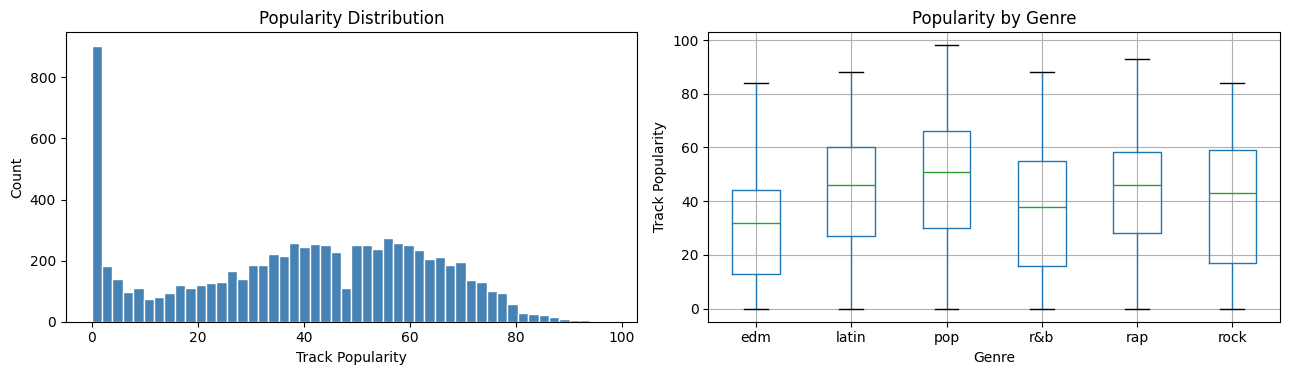

In [3]:
# track_popularity is our regression target (0–100 integer)
print('Popularity stats:')
print(df['track_popularity'].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['track_popularity'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Track Popularity')
axes[0].set_ylabel('Count')
axes[0].set_title('Popularity Distribution')

# Box-plot by genre
df.boxplot(column='track_popularity', by='playlist_genre', ax=axes[1])
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Track Popularity')
axes[1].set_title('Popularity by Genre')
plt.suptitle('')   # suppress pandas auto-title
plt.tight_layout()
plt.show()

In [6]:
SEED = 17

# Shuffle the full dataset
df_reg = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Dataset shape:', df_reg.shape)
print('Popularity range:', df_reg['track_popularity'].min(),
      '–', df_reg['track_popularity'].max())

# Target: track_popularity (continuous, 0–100)
y = df_reg['track_popularity'].values.astype(float)

Dataset shape: (7940, 23)
Popularity range: 0 – 98


In [ ]:
# convert genre to categorial type, then in integers
df_reg['playlist_genre'].astype('category').cat.codes

0       4
1       1
2       3
3       2
4       3
       ..
7935    4
7936    3
7937    5
7938    1
7939    3
Length: 7940, dtype: int8

In [26]:
df_reg['playlist_genre'] = df_reg['playlist_genre'].astype('category').cat.codes
df_features = df_reg[['danceability', 'energy', 'key', 'loudness', 'mode',
                       'speechiness', 'acousticness', 'instrumentalness',
                       'liveness', 'valence', 'tempo', 'duration_ms', 'playlist_genre']].copy()

df_features

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre
0,0.527,0.683,8,-5.023,1,0.0350,0.40700,0.000002,0.1010,0.1140,92.986,196000,4
1,0.685,0.912,10,-3.411,1,0.0687,0.05380,0.000000,0.3920,0.5110,99.957,235720,1
2,0.250,0.215,8,-13.676,0,0.0370,0.63200,0.071700,0.4010,0.0746,174.824,195987,3
3,0.738,0.934,6,-3.729,0,0.1200,0.00176,0.000000,0.0473,0.5470,104.970,201160,2
4,0.293,0.460,7,-6.992,1,0.0335,0.14000,0.000000,0.0779,0.1910,97.635,480547,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7935,0.618,0.211,9,-16.410,1,0.2080,0.87600,0.849000,0.0887,0.1420,83.982,85714,4
7936,0.345,0.327,9,-14.856,0,0.0610,0.93800,0.000378,0.1360,0.7220,163.377,270361,3
7937,0.566,0.521,7,-11.824,1,0.0321,0.51400,0.000288,0.1160,0.4680,129.167,299827,5
7938,0.839,0.913,3,-5.329,1,0.1660,0.26400,0.000000,0.0559,0.9560,115.585,243280,1


In [28]:
# Filter-based feature selection with f_regression
# f_regression computes the F-statistic between each feature and the
# continuous target, selecting the K features with the highest linear
# association with y.

K_BEST = 8

selector = SelectKBest(score_func=f_regression, k=K_BEST)
df_filter = selector.fit_transform(df_features, y)

selected_mask     = selector.get_support()
selected_features = df_features.columns[selected_mask].tolist()
print(f'Top {K_BEST} features selected:', selected_features)
print('Shape after selection:', df_filter.shape)

Top 8 features selected: ['danceability', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'liveness', 'duration_ms', 'playlist_genre']
Shape after selection: (7940, 8)


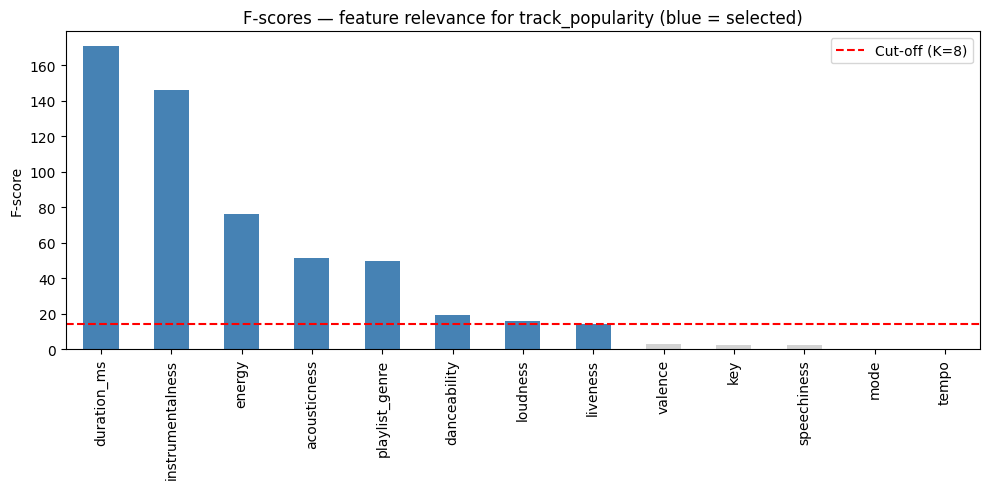

In [29]:
# Plot F-scores for all features
scores = pd.Series(selector.scores_, index=df_features.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
scores.plot(kind='bar',
            color=['steelblue' if f in selected_features else 'lightgrey'
                   for f in scores.index])
plt.axhline(scores.iloc[K_BEST - 1], color='red', linestyle='--',
            label=f'Cut-off (K={K_BEST})')
plt.title('F-scores — feature relevance for track_popularity (blue = selected)')
plt.ylabel('F-score')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Build final feature DataFrame from selected columns
X = pd.DataFrame(df_filter, columns=selected_features)
print('Final feature matrix shape:', X.shape)
X.head(3)

Final feature matrix shape: (7940, 8)


,danceability,energy,loudness,acousticness,instrumentalness,liveness,duration_ms,playlist_genre
0,0.527,0.683,-5.023,0.4070,0.000002,0.101,196000.0,4.0
1,0.685,0.912,-3.411,0.0538,0.000000,0.392,235720.0,1.0
2,0.250,0.215,-13.676,0.6320,0.071700,0.401,195987.0,3.0


In [31]:
# Train / test split  (no stratify — target is continuous)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
)

print('Train:', X_train.shape, '  Test:', X_test.shape)

Train: (6352, 8)   Test: (1588, 8)


In [32]:
# perform standardization over the numerical features of the dataset
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on training data only
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

In [ ]:
# Decision Tree Regressor
dt = DecisionTreeRegressor(max_depth=5, random_state=SEED)
dt.fit(X_train_sc, y_train)
y_pred = dt.predict(X_test_sc)

mse  = mean_squared_error(y_test, y_pred)

print(f'MSE  : {mse:.3f}')

MSE  : 537.020


In [40]:
mse  = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'MSE  : {mse:.3f}')
print(f'R²   : {r2:.4f}   (1 = perfect, 0 = mean baseline)')

MSE  : 537.020
R²   : 0.0547   (1 = perfect, 0 = mean baseline)


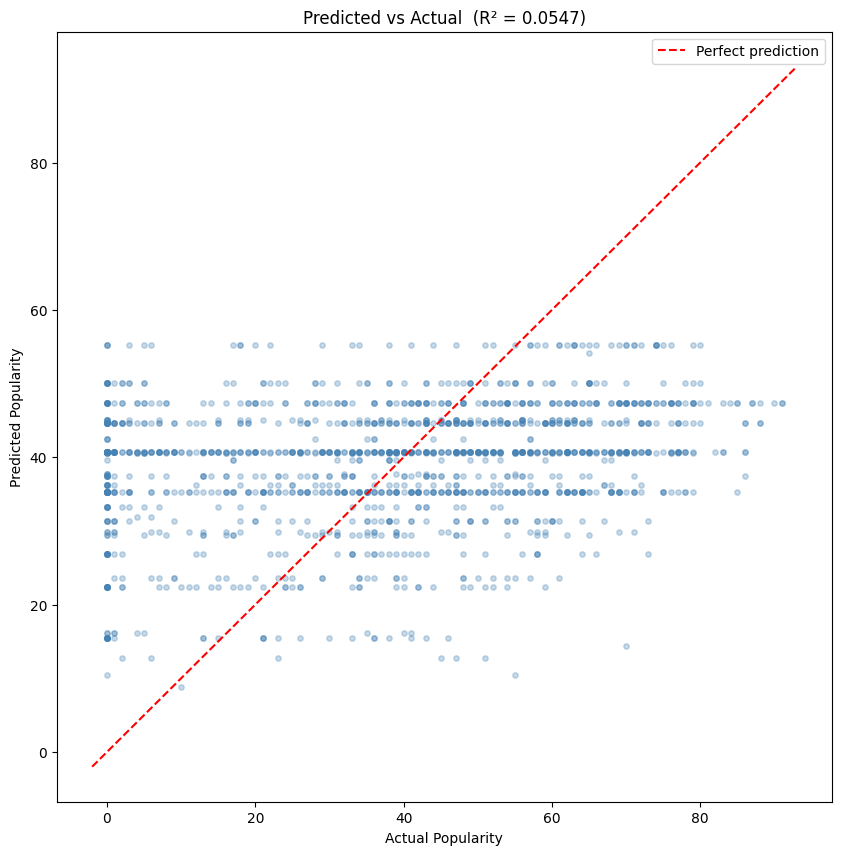

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))
# Predicted vs Actual 

ax.scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred.min()) - 2,
        max(y_test.max(), y_pred.max()) + 2]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Popularity')
ax.set_ylabel('Predicted Popularity')
ax.set_title(f'Predicted vs Actual  (R² = {r2:.4f})')
ax.legend()

plt.show()